# Lightweight Network Intrusion Detection System (IDS)
## CA2 Project – Problem Solving for Industry

**Students:**  
- Sander Luiz Santos Soares — **2022164**  
- Thiago Gonçalves da Costa — **2022161**

**College:** CCT College Dublin  
**Programme:** BSc (Hons) in Computing and IT  
**Module:** Problem Solving for Industry  
**Assessment:** CA2 Project  
**Lecturers:** Muhammad Iqbal, Ken Healy  
**Submission Type:** Jupyter Notebook / Python-based IDS prototype  

## Introduction

This project proposes the development of a **Lightweight Network Intrusion Detection System (IDS)** using **Python** and **machine learning** techniques to identify suspicious or potentially malicious network traffic. The main goal is to support the detection of anomalous behaviour in network flows and help organisations identify threats such as DoS, DDoS, brute force activity, port scanning, web attacks, infiltration, and other suspicious patterns.

The proposed solution is designed as a **lightweight and affordable prototype**, especially suitable for **small and medium-sized enterprises (SMEs)**, schools, clinics, small offices, and managed service providers that may not have dedicated cybersecurity teams or advanced monitoring infrastructure. The system aims to reduce the manual effort required to inspect traffic logs and improve the speed of suspicious traffic detection.

This notebook will document the technical development of the project, including **data understanding, preprocessing, feature selection, model training, evaluation, and prototype preparation**, following the logic of the **CRISP-DM framework** required in the CA2 brief. 

The project uses the **CIC-IDS2017** dataset, a public cybersecurity dataset developed by the **Canadian Institute for Cybersecurity**, containing labelled network traffic with both benign and malicious activity. This makes it suitable for building and testing machine learning models for intrusion detection.

The main technologies selected for this project are **Python**, **Scikit-learn**, and **Streamlit**. Python and Scikit-learn will be used for data preprocessing, machine learning model development, and evaluation, while Streamlit will support the creation of a simple dashboard interface for alerts and suspicious traffic summaries.

---

<h1 style="text-align: center;">1. Data Understanding</h3>

The purpose of this phase is to understand the structure, content, and quality of the CICIDS2017 dataset before applying any cleaning or preprocessing steps.

At this stage, the focus is on:
- understanding how the dataset is organised
- inspecting the available features and data types
- analysing the target variable and class distribution
- identifying early signs of data quality issues such as missing values, imbalance, and extreme values

This phase is important because a strong understanding of the dataset is necessary before moving into data cleaning, feature preparation, and model development.

## 1.1 Dataset Overview and Merging

The CICIDS2017 dataset is distributed across multiple CSV files, each representing different traffic periods and attack scenarios.

To support a more complete analysis, all source files are merged into a single unified dataframe. This allows the project to work with a broader representation of both benign and malicious traffic patterns, rather than restricting the analysis to one isolated subset.

At this stage, the objective is only to combine and inspect the full dataset. No cleaning or preprocessing is applied yet beyond basic column-name and text standardisation.

In [1]:
import pandas as pd
import glob

# Load all CICIDS2017 CSV files from the dataset folder
files = glob.glob("Datasets/CICIDS2017/*.csv")

# Read each CSV file and store them in a list of dataframes
df_list = [pd.read_csv(f) for f in files]

# Merge all source files into a single unified dataframe
df = pd.concat(df_list, ignore_index=True)

# Remove leading/trailing spaces from column names
df.columns = df.columns.str.strip()

# Clean non-ASCII characters and extra spaces from string columns
df = df.apply(
    lambda x: x.str.replace(r'[^\x00-\x7F]+', '', regex=True).str.strip()
    if x.dtype == "object" else x
)

# Display basic information about the merged dataset
print("Number of files loaded:", len(files))
print("Dataset shape:", df.shape)

Number of files loaded: 8
Dataset shape: (2830743, 79)


## 1.2 Source Files Overview

Although the CICIDS2017 dataset is merged into a single dataframe for analysis, it is originally composed of eight separate CSV files representing different traffic periods and attack scenarios.

Reviewing the source files individually helps provide additional context about the structure of the dataset and confirms that the final merged dataframe is built from multiple traffic conditions rather than a single isolated subset.

In [2]:
import os

# Create an empty list to store summary information for each source CSV file
source_file_summary = []

# Loop through each file path already stored in the 'files' variable
for f in files:
    # Read the current CSV file into a temporary dataframe
    temp_df = pd.read_csv(f)

    # Remove leading/trailing spaces from column names for consistency
    temp_df.columns = temp_df.columns.str.strip()

    # Append summary information for the current file
    source_file_summary.append({
        "File Name": os.path.basename(f),                # File name only
        "Rows": temp_df.shape[0],                        # Number of rows
        "Columns": temp_df.shape[1],                     # Number of columns
        "Classes": temp_df["Label"].nunique() if "Label" in temp_df.columns else None  # Number of label classes
    })

# Convert the list of dictionaries into a dataframe
source_file_summary_df = pd.DataFrame(source_file_summary)

# Display the summary table
source_file_summary_df

,File Name,Rows,Columns,Classes
0,Thursday-WorkingHours-Afternoon-Infilteration....,288602,79,2
1,Monday-WorkingHours.pcap_ISCX.csv,529918,79,1
2,Friday-WorkingHours-Morning.pcap_ISCX.csv,191033,79,2
3,Friday-WorkingHours-Afternoon-PortScan.pcap_IS...,286467,79,2
4,Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv,225745,79,2
5,Tuesday-WorkingHours.pcap_ISCX.csv,445909,79,3
6,Wednesday-workingHours.pcap_ISCX.csv,692703,79,6
7,Thursday-WorkingHours-Morning-WebAttacks.pcap_...,170366,79,4


#### Key observations:

- The merged dataset is built from eight source files with the same general structure.
- These files represent different traffic scenarios and different class compositions.
- This confirms that the final dataframe includes a broad mix of benign and malicious traffic patterns.
- The use of multiple source files increases the representativeness of the dataset for the IDS project.

---

## 1.3 Initial Data Exploration

After merging the datasets, an initial exploration is performed to understand the structure of the data. 
This includes examining the first rows, dataset dimensions, feature names, and data types.

In [3]:
# View first rows
df.head()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,22,166,1,1,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
1,60148,83,1,2,0,0,0,0,0.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
2,123,99947,1,1,48,48,48,48,48.0,0.0,...,40,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
3,123,37017,1,1,48,48,48,48,48.0,0.0,...,32,0.000,0.000,0,0,0.0,0.000,0,0,BENIGN
4,0,111161336,147,0,0,0,0,0,0.0,0.0,...,0,1753752.625,2123197.578,4822992,95,9463032.7,2657727.996,13600000,5700287,BENIGN


In [4]:
# Dataset shape
df.shape

(2830743, 79)

In [5]:
# Column names
df.columns

Index(['Destination Port', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [6]:
# Data types and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 79 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Destination Port             int64  
 1   Flow Duration                int64  
 2   Total Fwd Packets            int64  
 3   Total Backward Packets       int64  
 4   Total Length of Fwd Packets  int64  
 5   Total Length of Bwd Packets  int64  
 6   Fwd Packet Length Max        int64  
 7   Fwd Packet Length Min        int64  
 8   Fwd Packet Length Mean       float64
 9   Fwd Packet Length Std        float64
 10  Bwd Packet Length Max        int64  
 11  Bwd Packet Length Min        int64  
 12  Bwd Packet Length Mean       float64
 13  Bwd Packet Length Std        float64
 14  Flow Bytes/s                 float64
 15  Flow Packets/s               float64
 16  Flow IAT Mean                float64
 17  Flow IAT Std                 float64
 18  Flow IAT Max                 int64  
 19  

#### Key observations from the initial exploration:

- The merged dataset contains 2,830,743 rows and 79 columns, showing that the project is working with a large-scale intrusion detection dataset.
- The vast majority of features are numerical, with only the `Label` column stored as an object type.
- This is appropriate for machine learning, since most traditional algorithms in Scikit-learn are designed to work with numerical predictors.
- The dataset occupies a large amount of memory (approximately 1.7 GB), which reinforces the importance of efficient preprocessing and later feature reduction.
- At this stage, the dataset has been merged and standardised, but not yet cleaned.

---

## 1.4 Target Variable Analysis

The target variable in this dataset is the 'Label' column, which indicates whether a network flow is benign or corresponds to a specific type of attack.

To better understand the dataset, both the absolute count and percentage distribution of each class are analysed. This helps identify class imbalance, which is common in intrusion detection datasets and can impact model performance.

In [7]:
# Count values of each class
class_counts = df['Label'].value_counts()

# Percentage distribution
class_percentages = df['Label'].value_counts(normalize=True) * 100

# Combine into one table
class_distribution = pd.DataFrame({
    'Count': class_counts,
    'Percentage (%)': class_percentages
})

class_distribution

,Count,Percentage (%)
Label,,
BENIGN,2273097,80.300366
DoS Hulk,231073,8.162981
PortScan,158930,5.614427
DDoS,128027,4.522735
DoS GoldenEye,10293,0.363615
FTP-Patator,7938,0.280421
SSH-Patator,5897,0.208320
DoS slowloris,5796,0.204752
DoS Slowhttptest,5499,0.194260


#### Key observations:

- The dataset is highly imbalanced, with the `BENIGN` class representing the majority of the records.
- A small number of attack categories, such as `DoS Hulk`, `PortScan`, and `DDoS`, account for most of the malicious traffic.
- Some attack types are extremely rare, including `Infiltration`, `Web Attack Sql Injection`, and `Heartbleed`.
- This imbalance is especially important in a multi-class intrusion detection setting, because rare classes are harder for machine learning models to learn correctly.
- These results confirm that class imbalance will be a central issue in later stages of the project.

At this stage, the target analysis is used only to understand the dataset structure. Decisions related to label encoding, resampling, or class balancing will be addressed later during data preparation and modelling.

---

## 1.5 Missing Values Analysis

Checking for missing values is important to ensure data quality.<br>
Missing values can negatively impact model performance and must be handled during data preparation.

In [8]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

Flow Bytes/s            1358
Destination Port           0
Bwd Avg Bytes/Bulk         0
Fwd Avg Packets/Bulk       0
Fwd Avg Bytes/Bulk         0
                        ... 
Bwd IAT Mean               0
Bwd IAT Total              0
Fwd IAT Min                0
Fwd IAT Max                0
Label                      0
Length: 79, dtype: int64

**Key observations:**

- Missing values are very limited relative to the total size of the dataset.
- The feature `Flow Bytes/s` is the only column currently showing missing values in the merged dataframe.
- Although the number of affected rows is small, these values still need to be addressed before machine learning preparation.

At this stage, the objective is only to identify the presence of missing values. The final handling strategy will be applied later in the Data Cleaning phase, together with additional checks for duplicated rows, infinite values, and constant features.

---

## 1.6 Statistical Summary

A statistical summary of numerical features is generated to understand the distribution, central tendency, and variability of the dataset. This helps identify potential anomalies and outliers.

In [9]:
df.describe()

,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,...,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06,2.830743e+06
mean,8.071483e+03,1.478566e+07,9.361160e+00,1.039377e+01,5.493024e+02,1.616264e+04,2.075999e+02,1.871366e+01,5.820194e+01,6.891013e+01,...,5.418218e+00,-2.741688e+03,8.155132e+04,4.113412e+04,1.531825e+05,5.829582e+04,8.316037e+06,5.038439e+05,8.695752e+06,7.920031e+06
std,1.828363e+04,3.365374e+07,7.496728e+02,9.973883e+02,9.993589e+03,2.263088e+06,7.171848e+02,6.033935e+01,1.860912e+02,2.811871e+02,...,6.364257e+02,1.084989e+06,6.485999e+05,3.933815e+05,1.025825e+06,5.770923e+05,2.363008e+07,4.602984e+06,2.436689e+07,2.336342e+07
min,0.000000e+00,-1.300000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,-5.368707e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,5.300000e+01,1.550000e+02,2.000000e+00,1.000000e+00,1.200000e+01,0.000000e+00,6.000000e+00,0.000000e+00,6.000000e+00,0.000000e+00,...,0.000000e+00,2.000000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,8.000000e+01,3.131600e+04,2.000000e+00,2.000000e+00,6.200000e+01,1.230000e+02,3.700000e+01,2.000000e+00,3.400000e+01,0.000000e+00,...,1.000000e+00,2.400000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,4.430000e+02,3.204828e+06,5.000000e+00,4.000000e+00,1.870000e+02,4.820000e+02,8.100000e+01,3.600000e+01,5.000000e+01,2.616295e+01,...,2.000000e+00,3.200000e+01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,6.553500e+04,1.200000e+08,2.197590e+05,2.919220e+05,1.290000e+07,6.554530e+08,2.482000e+04,2.325000e+03,5.940857e+03,7.125597e+03,...,2.135570e+05,1.380000e+02,1.100000e+08,7.420000e+07,1.100000e+08,1.100000e+08,1.200000e+08,7.690000e+07,1.200000e+08,1.200000e+08


#### Key observations:

- Many numerical features show very large ranges between minimum and maximum values.
- Several variables have medians close to zero but very large maximum values, suggesting strong skewness and long-tailed distributions.
- The large gap between mean, median, and maximum values indicates that extreme observations are common in the dataset.
- In network traffic analysis, these extreme values are not necessarily errors. They may reflect bursts of traffic, attack behaviour, or legitimate high-volume flows.
- However, from a machine learning perspective, these scale differences may affect model behaviour and reinforce the need for feature scaling in later stages.

These observations support the conclusion that the dataset is realistic and behaviourally rich, but also challenging from a preprocessing and modelling perspective.a.

---

## 1.7 Conclusion of Data Understanding:

The Data Understanding phase confirms that the CICIDS2017 dataset is appropriate for the development of a machine learning-based intrusion detection prototype.

The analysis shows that:

- the dataset is large and contains a wide range of labelled traffic behaviours
- the features are predominantly numerical, which is suitable for Scikit-learn models
- the target variable is highly imbalanced in the multi-class setting
- a small number of missing values are present
- the data contains large ranges, skewed distributions, and many extreme values

These findings suggest that careful cleaning and preparation will be necessary before modelling. In particular, the project will need to address data quality issues, class imbalance, and feature redundancy while preserving the behaviour patterns that are important for intrusion detection.

## 1.8 Additional Data Quality Observations


Although the dataset has already been explored at a structural level, some important quality issues are still expected to exist in the merged dataframe.

Based on the characteristics of the CICIDS2017 source files, the next stages of the project will need to investigate:

- duplicated rows
- infinite values in flow-rate related features
- constant or near-constant features
- highly correlated features that may introduce redundancy

These issues are particularly relevant because the project aims to develop a lightweight IDS, meaning that the dataset should not only be valid for machine learning, but also efficient enough to support a reduced and practical model.

---

<h1 style="text-align: center;">2. Exploratory Data Analysis (EDA) – Multi-Class IDS</h3>

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

## 2.1 Class Distribution (Multi-Class)

The dataset is treated as a multi-class classification problem, where each class represents a specific type of network traffic, including benign traffic and various attack categories such as DDoS, PortScan, and Web Attacks.

Visualising the class distribution helps identify class imbalance and understand how different attack types are represented in the dataset.

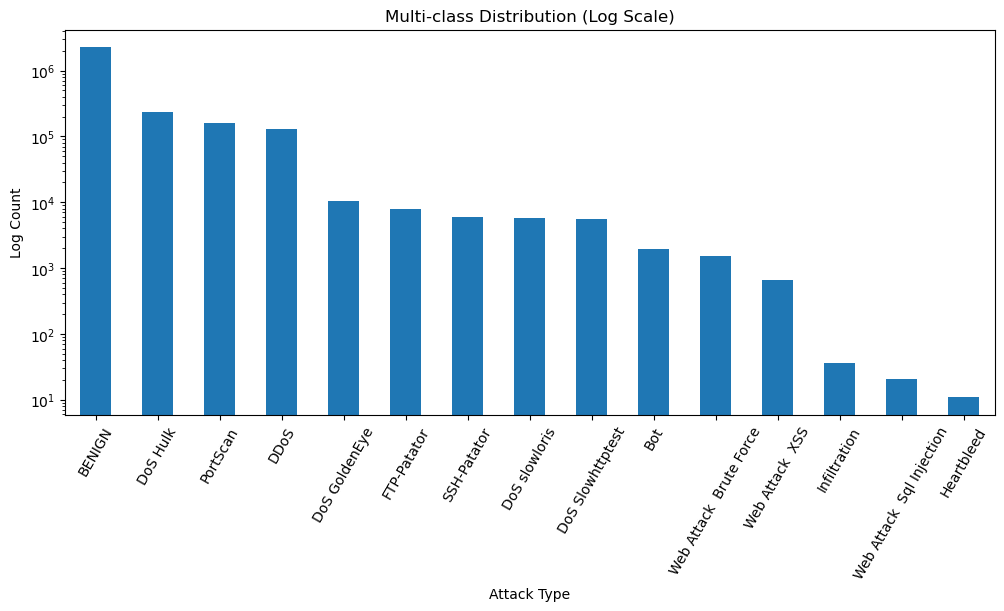

In [15]:
df['Label'].value_counts().plot(kind='bar', figsize=(12,5))

plt.yscale('log')  # KEY CHANGE

plt.title("Multi-class Distribution (Log Scale)")
plt.xlabel("Attack Type")
plt.ylabel("Log Count")
plt.xticks(rotation=60)
plt.show()

#### Key Observations

- The dataset is highly imbalanced, where the BENIGN class is much bigger than all other classes.
- Some attack types like DoS Hulk, PortScan and DDoS appear much more frequently compared to others.
- Other attacks such as Infiltration, SQL Injection and Heartbleed have very small number of samples.
- The use of logarithmic scale helps to visualise smaller classes which would not be visible in a normal scale.
- This imbalance can affect the machine learning model, so techniques like resampling or class weighting will be needed.
- This distribution also reflects real network traffic, where normal activity is more common and some attacks happen rarely but are still important to detect.

---

## 2.2 Correlation Analysis

A correlation matrix is used to analyse relationships between numerical features. Highly correlated features may indicate redundancy and can be removed in later stages to simplify the model and improve efficiency.

Due to the large number of features, the full correlation matrix can be difficult to interpret. Therefore, only strongly correlated features (|correlation| > 0.8) are visualised to highlight meaningful relationships and identify redundant features.

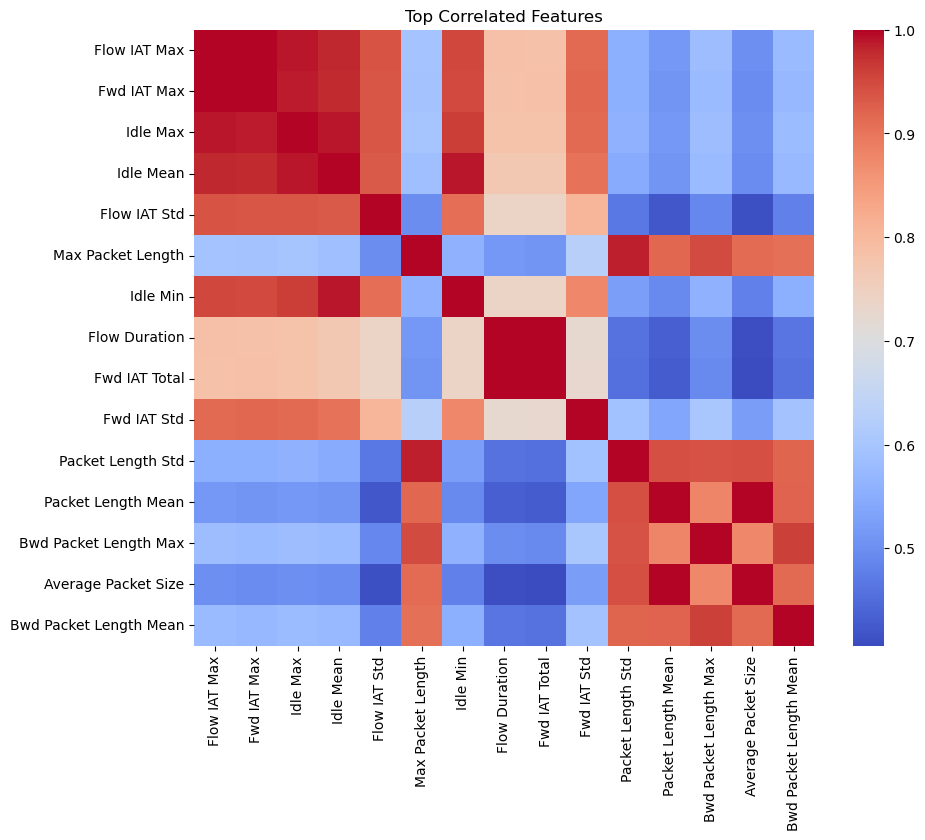

In [12]:
# Select only numerical features for correlation analysis
numeric_df = df.select_dtypes(include=['number'])

# Get top correlated features
corr_matrix = numeric_df.corr().abs()

# Select top features with highest correlation sums
top_features = corr_matrix.sum().sort_values(ascending=False).head(15).index

# Plot only those
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df[top_features].corr(), cmap='coolwarm')
plt.title("Top Correlated Features")
plt.show()

#### Key Observations

- Some features show very strong correlation with each other, especially related to IAT (Inter-Arrival Time) and packet length metrics.
- Features like Flow IAT Max, Fwd IAT Max, Idle Max and Idle Mean appear highly correlated, which means they may contain similar information.
- Packet-related features such as Packet Length Mean, Packet Length Std, and Average Packet Size also show strong relationships.
- This indicates possible redundancy in the dataset, where multiple features describe similar behaviour of network traffic.
- Keeping all highly correlated features may increase model complexity without improving performance.
- Therefore, feature selection will be important.

---

## 2.3 Outlier Analysis

Boxplots are used to detect extreme values in selected features. Network traffic data naturally exhibits high variability due to differences in flow duration, packet sizes, and transmission rates.

There is no single feature that directly determines whether a flow is an attack. Instead, attacks are identified based on patterns across multiple features. Machine learning models are required to learn these multi-dimensional relationships rather than relying on predefined rules.

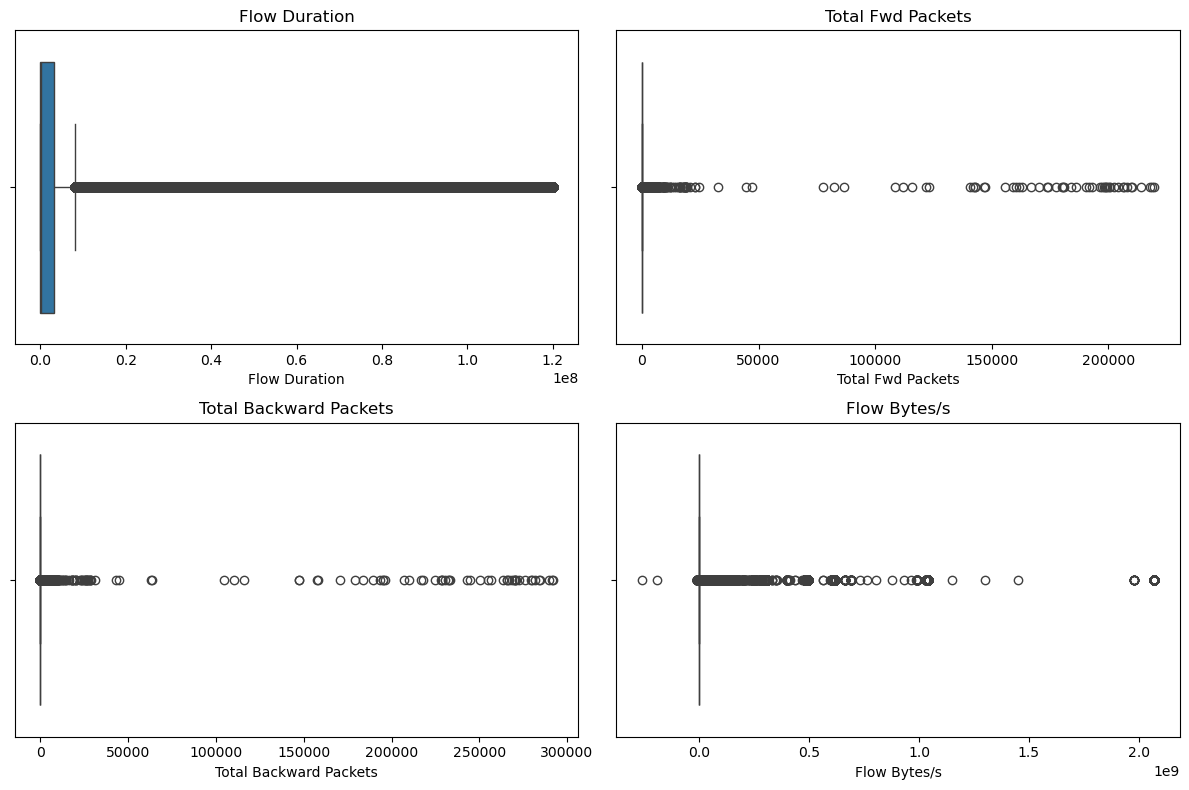

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select 4 features
features = [
    'Flow Duration',
    'Total Fwd Packets',
    'Total Backward Packets',
    'Flow Bytes/s'
]

# Create 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Flatten axes for easy looping
axes = axes.flatten()

# Plot each feature
for i, feature in enumerate(features):
    sns.boxplot(x=df[feature], ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()

#### Key Observations

- All selected features show presence of extreme values, which appear as many points outside the boxplot range.
- Most of the data is concentrated near lower values, while a small number of observations extend to very large values.
- This indicates that the data is highly skewed, with long tails in the distribution.
- From a networking perspective, these extreme values are expected, as network traffic can vary significantly depending on the type of activity.
- Therefore, these values are not considered errors, but normal behaviour of network flows.
- However, for machine learning models, such large variations may affect performance.
- For this reason, feature scaling will be applied in the data preparation phase instead of removing these values.

---

<h1 style="text-align: center;">3. Data Cleaning</h3>

The purpose of this phase is to identify and address data quality issues that may negatively affect later preprocessing and machine learning steps.

At this stage, the cleaning process focuses on:

- detecting infinite values
- reviewing missing values after conversion
- removing incomplete records where appropriate
- identifying and removing duplicate rows
- detecting constant features that do not contribute useful information
- checking the consistency of the target labels

The goal is to improve the reliability and consistency of the dataset while preserving the behavioural patterns that are important for intrusion detection.

## 3.1 Purpose of Data Cleaning

Although the dataset has already been explored in the Data Understanding phase, the merged dataframe may still contain hidden quality issues that are common in network traffic datasets.

Cleaning is necessary before preparation because machine learning models require data that is structurally consistent, free from invalid numeric values, and suitable for later transformation steps such as encoding, scaling, and splitting.

## 3.2 Infinite Value Detection

In intrusion detection datasets, some flow-rate related features may contain infinite values. These values are not always visible in a standard missing value check, but they can break later preprocessing steps such as scaling and modelling.

For this reason, the dataset is explicitly checked for positive and negative infinite values before handling missing data.

In [17]:
import numpy as np

# Select only numerical columns for infinite value inspection
numeric_df = df.select_dtypes(include=[np.number])

# Count infinite values per numerical column
inf_mask = np.isinf(numeric_df)
inf_counts = pd.Series(inf_mask.sum(), index=numeric_df.columns)

# Display only columns that contain infinite values
inf_counts[inf_counts > 0].sort_values(ascending=False)

Flow Packets/s    2867
Flow Bytes/s      1509
dtype: int64

#### Key observations:

- Infinite values are expected mainly in rate-based features such as `Flow Bytes/s` and `Flow Packets/s`.
- These values must be addressed before missing value handling, because many machine learning tools cannot process infinite values directly.
- Converting infinite values into missing values is an appropriate intermediate step before final cleaning.

## 3.3 Missing Value Handling

After identifying infinite values, they are converted into missing values so that the dataset can be cleaned consistently.

The dataset is then rechecked for missing values. Because the number of affected records is very small relative to the total dataset size, removing incomplete rows is considered an appropriate and practical cleaning strategy at this stage.

In [18]:
# Convert positive and negative infinite values into NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Recalculate missing values after converting infinities
missing_after_inf = df.isnull().sum().sort_values(ascending=False)

# Display only columns with missing values
missing_after_inf[missing_after_inf > 0]

Flow Packets/s    2867
Flow Bytes/s      2867
dtype: int64

In [19]:
# Store the number of rows before removing missing values
rows_before_dropna = df.shape[0]

# Remove rows that contain missing values
df = df.dropna()

# Store the number of rows after removing missing values
rows_after_dropna = df.shape[0]

# Display the impact of missing value removal
print("Rows before dropping missing values:", rows_before_dropna)
print("Rows after dropping missing values:", rows_after_dropna)
print("Rows removed:", rows_before_dropna - rows_after_dropna)

Rows before dropping missing values: 2830743
Rows after dropping missing values: 2827876
Rows removed: 2867


#### Key observations:

- Missing values remain limited in proportion to the full dataset, even after converting infinite values into `NaN`.
- Since the number of affected rows is very small compared to more than 2.8 million records, removing them is unlikely to harm the overall representativeness of the dataset.
- This approach keeps the cleaning stage simple, transparent, and appropriate for the current phase of the project.

## 3.4 Duplicate Row Detection and Removal

Duplicate records can distort machine learning results by over-representing repeated patterns and inflating model performance. Since the CICIDS2017 source files are known to contain duplicates in several subsets, the merged dataframe is checked and cleaned accordingly.

In [20]:
# Count duplicate rows in the cleaned dataframe
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 307078


In [21]:
# Store the number of rows before removing duplicates
rows_before_dedup = df.shape[0]

# Remove duplicate rows
df = df.drop_duplicates()

# Store the number of rows after removing duplicates
rows_after_dedup = df.shape[0]

# Display the impact of duplicate removal
print("Rows before dropping duplicates:", rows_before_dedup)
print("Rows after dropping duplicates:", rows_after_dedup)
print("Duplicate rows removed:", rows_before_dedup - rows_after_dedup)

Rows before dropping duplicates: 2827876
Rows after dropping duplicates: 2520798
Duplicate rows removed: 307078


#### Key observations:

- Duplicate rows are present in the merged dataset and should not be ignored.
- Removing duplicates helps prevent repeated traffic records from biasing the learning process.
- This step is especially important in intrusion detection, where repeated flows can artificially strengthen certain patterns if left untreated.